<a href="https://colab.research.google.com/github/xyhosino/DeepLearning/blob/main/%E6%9C%BA%E5%99%A8%E5%AD%A6%E4%B9%A0_%E7%AC%AC5%E8%AF%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
df_bank = pd.read_csv('/content/drive/MyDrive/learning_data/BankCustomer.csv')
df_bank.head()

,Name,Gender,Age,City,Tenure,ProductsNo,HasCard,ActiveMember,Credit,AccountBal,Salary,Exited
0,Kan Jian,Female,40,Beijing,9,2,0,1,516,6360.66,0.0000,0
1,Xue Baochai,Male,69,Beijing,6,2,0,1,682,28605.00,0.0000,0
2,Mao Xi,Female,32,Beijing,9,1,1,1,803,10378.09,236311.0932,1
3,Zheng Nengliang,Female,37,Tianjin,0,2,1,1,778,25564.01,129909.8079,1
4,Zhi Fen,Male,55,Tianjin,4,3,1,0,547,3235.61,136976.1948,1


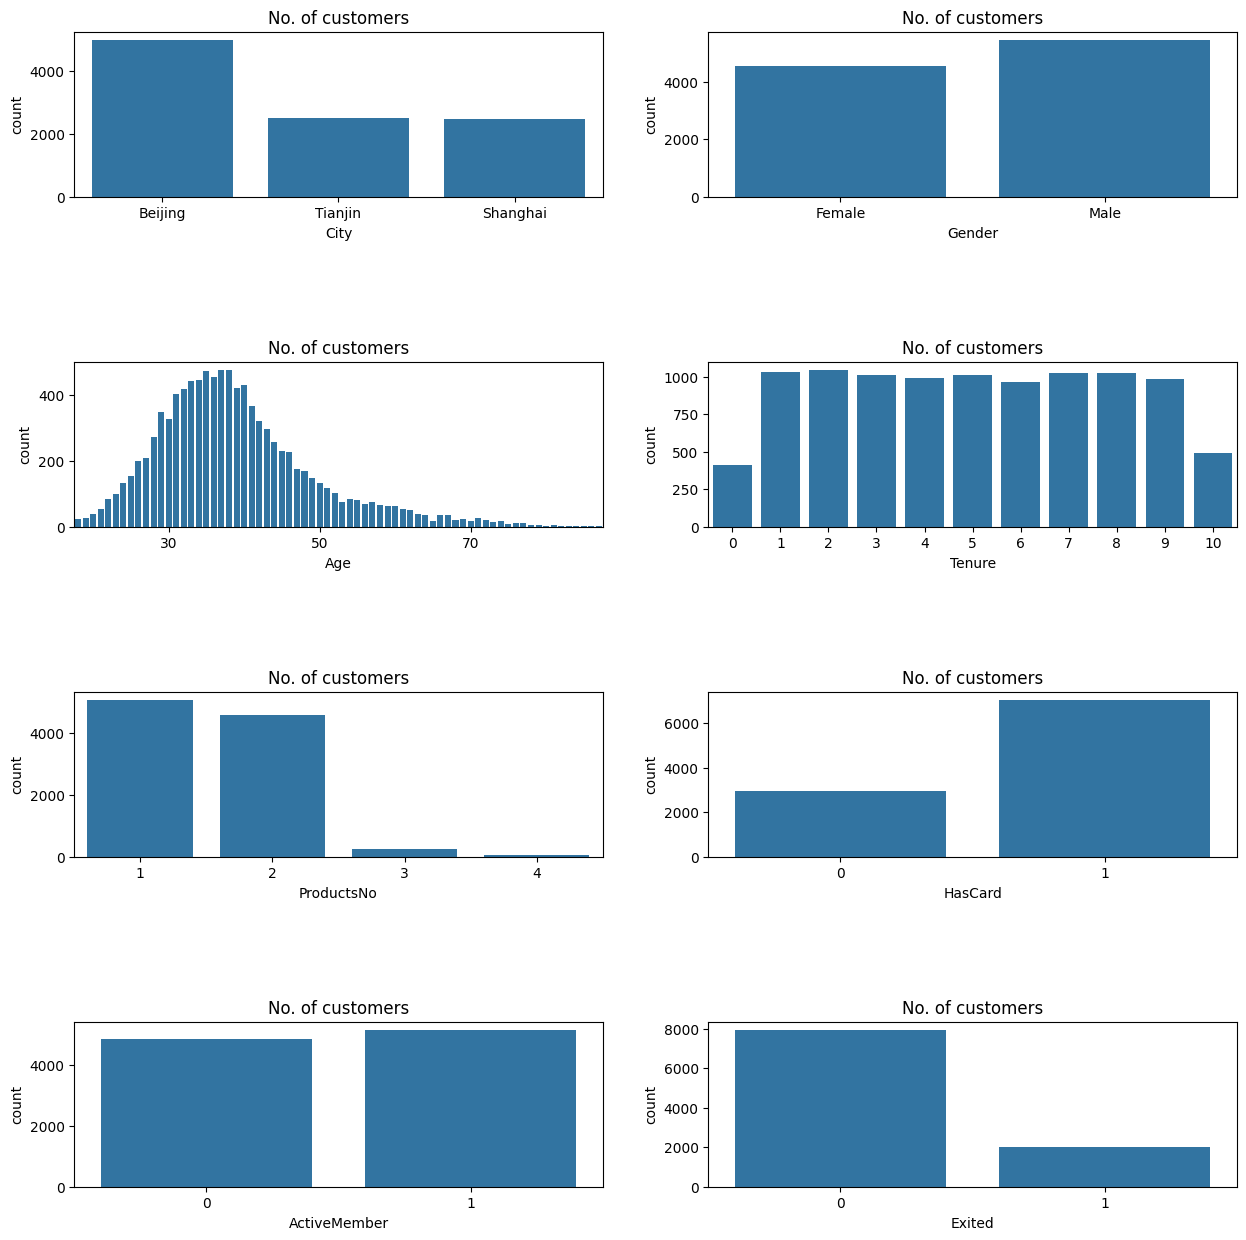

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['City', 'Gender', 'Age', 'Tenure',
            'ProductsNo', 'HasCard', 'ActiveMember', 'Exited']

plt.figure(figsize=(15,15))

for i, j in enumerate(features):
    plt.subplot(4, 2, i+1)  #画布分为4行2列，并在第i+1个位置创建当前子图
    sns.countplot(x=j, data=df_bank)  #自动统计特征j中每个类别的数量，并画成柱状图（计数图）
    plt.title('No. of customers')  #给每个小图加上“No. of customers”的标题

    if j == 'Age':
        plt.xticks([12,32,52])  #从0开始，只显示第12、32、52三个刻度

plt.subplots_adjust(hspace=1.0)  #增加了子图之间垂直方向的间距，防止上方图片的标题和下方图片的坐标轴标签重叠
plt.show()


In [3]:
#把二元类别文本数字化
df_bank['Gender'] = df_bank['Gender'].replace({'Female': 0, 'Male': 1})
#显示数字类别
print("Gender unique values", df_bank['Gender'].unique())
#把多元类别转换成多个二元类别哑变量，然后放回原始数据集
df_city = pd.get_dummies(df_bank['City'], prefix='City') #"prefix"为新生成的每一列“独热变量”添加一个统一的前缀
df_bank=[df_bank,df_city]
df_bank=pd.concat(df_bank,axis=1)
#构建特征和标签集合
y = df_bank['Exited'] #客户是否流失（Exited）
x = df_bank.drop(['Name', 'Exited', 'City'], axis=1) #drop删除不需要的列
x.head() #显示新的特征集

Gender unique values [0 1]


/tmp/ipykernel_18938/498257324.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bank['Gender'] = df_bank['Gender'].replace({'Female': 0, 'Male': 1})


,Gender,Age,Tenure,ProductsNo,HasCard,ActiveMember,Credit,AccountBal,Salary,City_Beijing,City_Shanghai,City_Tianjin
0,0,40,9,2,0,1,516,6360.66,0.0000,True,False,False
1,1,69,6,2,0,1,682,28605.00,0.0000,True,False,False
2,0,32,9,1,1,1,803,10378.09,236311.0932,True,False,False
3,0,37,0,2,1,1,778,25564.01,129909.8079,False,False,True
4,1,55,4,3,1,0,547,3235.61,136976.1948,False,False,True


In [4]:
from sklearn.model_selection import train_test_split

# 拆分数据集
# test_size=0.2: 表示测试集占总数据的20%
# random_state=42: 这是一个随机种子，填任何整数都可以。它的作用是固定随机结果，保证你每次运行代码切分出的数据都是一样的（方便复现）。
# stratify=y: (强烈推荐)按照标签y的比例进行分层抽样。比如原始数据中流失用户占20%，那么分层拆分后，训练集和测试集中的流失用户也都各占20%。
# x_train, x_test, y_train, y_test顺序固定
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# 打印结果查看形状 (行数, 列数)
print(f"训练集特征 (x_train) 形状: {x_train.shape}")
print(f"测试集特征 (x_test)  形状: {x_test.shape}")
print(f"训练集标签 (y_train) 形状: {y_train.shape}")
print(f"测试集标签 (y_test)  形状: {y_test.shape}")

训练集特征 (x_train) 形状: (8000, 12)
测试集特征 (x_test)  形状: (2000, 12)
训练集标签 (y_train) 形状: (8000,)
测试集标签 (y_test)  形状: (2000,)


In [5]:
# 列出所有特征列名
print(x_train.columns.tolist())

['Gender', 'Age', 'Tenure', 'ProductsNo', 'HasCard', 'ActiveMember', 'Credit', 'AccountBal', 'Salary', 'City_Beijing', 'City_Shanghai', 'City_Tianjin']


In [6]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
history=lr.fit(x_train,y_train)
print('逻辑回归预测准确率 {:.2f}%'.format(lr.score(x_test,y_test)*100))

逻辑回归预测准确率 79.45%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. 重新准备数据（确保使用去重后的 x）
# x = x.loc[:, ~x.columns.duplicated()] # 如果之前没去重，请取消注释

# 2. 数据标准化
scaler = StandardScaler()
# 注意：fit_transform 只能在训练集上用，测试集只能用 transform 保持一致性
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 3. 建立模型并增加迭代次数
# solver='lbfgs' 是默认优化器，max_iter 给够 1000 次通常就收敛了
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train)

# 4. 打印准确率
print('标准化后逻辑回归准确率: {:.2f}%'.format(lr.score(x_test_scaled, y_test) * 100))

标准化后逻辑回归准确率: 80.55%


In [8]:
from sklearn.metrics import classification_report

y_pred = lr.predict(x_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.57      0.17      0.27       407

    accuracy                           0.81      2000
   macro avg       0.70      0.57      0.58      2000
weighted avg       0.77      0.81      0.76      2000



In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. 初始化随机森林分类器
# n_estimators=100: 表示森林里有 100 棵决策树
# max_depth=10: 限制树的最大深度，防止模型“死记硬背”（过拟合）
# random_state=42: 保证结果可复现
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# 2. 训练模型
# 注意：随机森林可以直接用原始的 x_train，不需要缩放
rf.fit(x_train, y_train)

# 3. 预测并打分
print('随机森林预测准确率: {:.2f}%'.format(rf.score(x_test, y_test) * 100))

# 4. 查看详细的分类报告
y_pred_rf = rf.predict(x_test)
print("\n分类报告:")
print(classification_report(y_test, y_pred_rf))

随机森林预测准确率: 85.05%

分类报告:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1593
           1       0.76      0.39      0.51       407

    accuracy                           0.85      2000
   macro avg       0.81      0.68      0.71      2000
weighted avg       0.84      0.85      0.83      2000



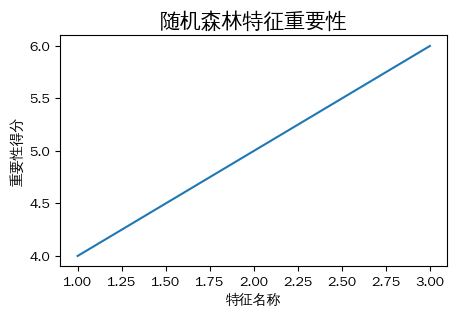

In [10]:
# 1. 安装中文字体 (以黑体为例)
!apt-get -qq -y install fonts-wqy-zenhei

# 2. 设置 Matplotlib 运行参数
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# 清除旧的缓存目录，否则它找不到新安装的字体
!rm -rf ~/.cache/matplotlib

# 这里的 'Zen Hei' 对应刚刚安装的 WenQuanYi Zen Hei 字体
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示为方块的问题

# 3. 验证一下
plt.figure(figsize=(5,3))
plt.plot([1, 2, 3], [4, 5, 6])
plt.title('随机森林特征重要性', fontsize=15)
plt.xlabel('特征名称')
plt.ylabel('重要性得分')
plt.show()

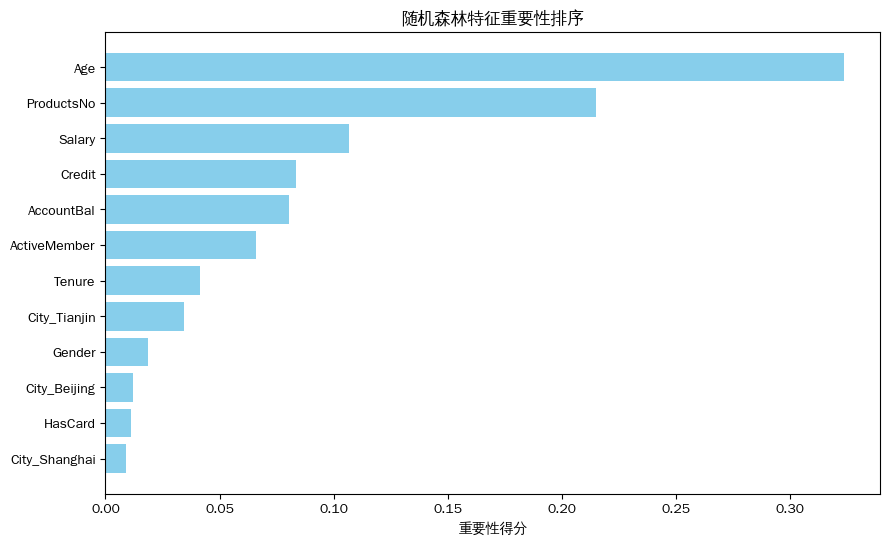

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# 获取特征重要性
importances = rf.feature_importances_
feature_names = x.columns
feature_importance_df = pd.DataFrame({'特征': feature_names, '重要性': importances})
feature_importance_df = feature_importance_df.sort_values(by='重要性', ascending=False)

# 可视化
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['特征'], feature_importance_df['重要性'], color='skyblue')
plt.xlabel('重要性得分')
plt.title('随机森林特征重要性排序')
plt.gca().invert_yaxis() # 重要性最高的排在上面
plt.show()

In [12]:
import numpy as np
from sklearn.metrics import classification_report

# 1. 获取模型预测的原始概率 (第2列是流失的概率)
y_probs = rf.predict_proba(x_test)[:, 1]

# 2. 设定一个新的阈值 (比如 0.3)
# 只要模型认为流失概率超过 30%，我们就标记为 1 (流失)
new_threshold = 0.3
y_pred_new = (y_probs >= new_threshold).astype(int)

# 3. 查看新的分类报告
print(f"--- 阈值调整为 {new_threshold} 后的分类报告 ---")
print(classification_report(y_test, y_pred_new))

--- 阈值调整为 0.3 后的分类报告 ---
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1593
           1       0.61      0.60      0.61       407

    accuracy                           0.84      2000
   macro avg       0.76      0.75      0.76      2000
weighted avg       0.84      0.84      0.84      2000



In [13]:
import pandas as pd

def predict_churn_risk(customer_data, model, feature_columns):
    """
    输入客户信息字典，返回流失风险评估。
    """
    # 1. 将输入字典转换为 DataFrame
    input_df = pd.DataFrame([customer_data])

    # 2. 确保列的顺序与模型训练时完全一致，缺失列补0
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)

    # 3. 获取预测概率
    prob = model.predict_proba(input_df)[0][1]

    # 4. 定义风险等级逻辑
    if prob < 0.3:
        risk_level = "低风险"
        suggestion = "客户忠诚度高，维持现状即可。"
    elif 0.3 <= prob < 0.6:
        risk_level = "中风险"
        suggestion = "客户有流失苗头，建议推送优惠券或理财产品增加粘性。"
    else:
        risk_level = "高风险"
        suggestion = "流失风险极高！建议人工介入，进行专属客户关怀。"

    return {
        "流失概率": f"{prob*100:.2f}%",
        "风险等级": risk_level,
        "建议方案": suggestion
    }

In [14]:
# 定义特征列名列表（确保是你之前 x_train.columns 的顺序）
features = x_train.columns.tolist()

# 模拟一位 50 岁、信用分较低、且只有一个产品的客户
test_customer = {
    'Gender': 1,
    'Age': 50,
    'Tenure': 2,
    'ProductsNo': 1,
    'HasCard': 1,
    'ActiveMember': 0,
    'Credit': 500,
    'AccountBal': 10000,
    'Salary': 50000,
    'City_Beijing': 1,  # 假设他在北京
    'City_Shanghai': 0,
    'City_Tianjin': 0
}

# 调用函数
result = predict_churn_risk(test_customer, rf, features)

print("--- 客户流失风险报告 ---")
for key, value in result.items():
    print(f"{key}: {value}")

--- 客户流失风险报告 ---
流失概率: 59.30%
风险等级: 中风险
建议方案: 客户有流失苗头，建议推送优惠券或理财产品增加粘性。


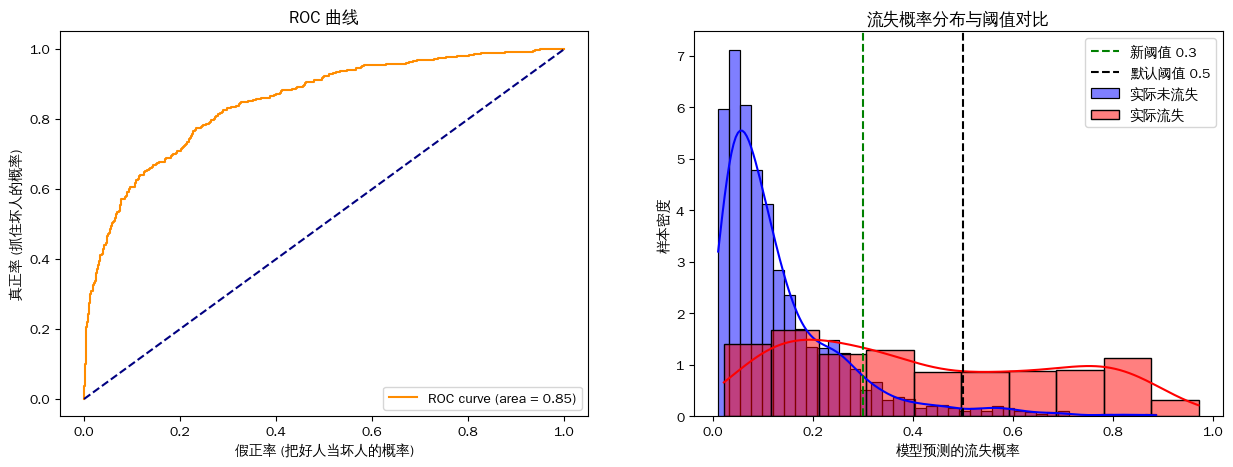

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# 1. 计算 ROC 曲线数据
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 2. 计算 精确率-召回率 曲线数据
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_probs)

# 3. 绘图
plt.figure(figsize=(15, 5))

# 图 1: ROC 曲线（评估模型整体分类能力）
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('假正率 (把好人当坏人的概率)')
plt.ylabel('真正率 (抓住坏人的概率)')
plt.title('ROC 曲线')
plt.legend(loc="lower right")

# 图 2: 概率分布图（决定阈值该放哪）
plt.subplot(1, 2, 2)
import seaborn as sns
sns.histplot(y_probs[y_test == 0], color="blue", label="实际未流失", kde=True, stat="density")
sns.histplot(y_probs[y_test == 1], color="red", label="实际流失", kde=True, stat="density")
plt.axvline(0.3, color='green', linestyle='--', label='新阈值 0.3')
plt.axvline(0.5, color='black', linestyle='--', label='默认阈值 0.5')
plt.xlabel('模型预测的流失概率')
plt.ylabel('样本密度')
plt.title('流失概率分布与阈值对比')
plt.legend()

plt.show()

In [36]:
import keras
from keras.models import Sequential #导入Keras序贯模型
from keras.layers import Dense #导入Keras全连接层
ann=Sequential()
# units=12：12个神经元，input_dim=12：12个特征，activation='relu')：激活函数为'relu'
# input_dim输入层，units、activation隐藏层
ann.add(Dense(units=12,input_dim=12,activation='relu')) #添加输入层
ann.add(Dense(units=24,activation='relu')) #添加隐层
# Sigmoid函数会将输出压缩到0-1之间，可以直接解释为“流失的概率”。
ann.add(Dense(units=1,activation='sigmoid')) #添加输出层
ann.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 24)             │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 493 (1.93 KB)

 Trainable params: 493 (1.93 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
!pip install pydot
!apt-get install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


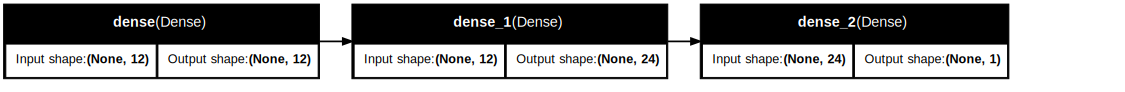

In [18]:
from IPython.display import SVG, display
from tensorflow.keras.utils import model_to_dot

# 1. 使用 model_to_dot 生成图形
# rankdir='LR' 会让模型从左向右横向排列，通常比纵向更省空间
dot_data = model_to_dot(
    ann,
    show_shapes=True,
    show_layer_names=True,
    rankdir='LR',  # 尝试 'TB' 是从上到下，'LR' 是从左到右
    dpi=65         # 降低 DPI 可以直接缩小图片体积
)

# 2. 渲染并手动限制显示宽度（比如限制为页面宽度的 80%）
svg_obj = SVG(dot_data.create(prog='dot', format='svg'))
display(svg_obj)

In [26]:
from tensorflow.keras.utils import plot_model
from google.colab import files

# 确保你之前运行过这行代码：
plot_model(ann, to_file='model_structure.png', show_shapes=True)

# 运行下面这行，浏览器会自动下载图片
files.download('model_structure.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
ann.compile(optimizer='adam',        #优化器
     loss='binary_crossentropy',    #损失函数
     metrics=['acc'])         #评估指标

In [23]:
# Dense层中可设置的参数
keras.layers.Dense(units=12,
      activation=None,
      use_bias=True,            #是否使用偏置项
      kernel_initializer='glorot_uniform', #权重的初始分配方式
      bias_initializer='zeros',      #偏置默认全部设为0
      kernel_regularizer=None,       #对权重进行惩罚
      bias_regularizer=None,        #对偏置进行惩罚
      activity_regularizer=None,      #该层的输出结果进行惩罚
      kernel_constraint=None,       #权重约束参数
      bias_constraint=None)        #偏置约束参数

<Dense name=dense_3, built=False>

In [24]:
history=ann.fit(x_train, y_train,
        epochs=30,
        batch_size=64,
        validation_data=(x_test, y_test))
# 查看最后一轮的准确率
print(f"最终验证集准确率: {history.history['val_acc'][-1]:.2%}")

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - acc: 0.6313 - loss: 1067.1332 - val_acc: 0.7140 - val_loss: 117.2699
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.6909 - loss: 49.3944 - val_acc: 0.4665 - val_loss: 89.3693
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.6848 - loss: 29.6722 - val_acc: 0.4630 - val_loss: 36.3379
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.6855 - loss: 31.7714 - val_acc: 0.3145 - val_loss: 46.4813
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.6885 - loss: 24.1698 - val_acc: 0.7940 - val_loss: 31.4592
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.6877 - loss: 32.4159 - val_acc: 0.7955 - val_loss: 35.8451
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.6899 - loss: 23.8061 - val_acc: 0.7975 - val_loss: 49.4414
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.6889 - loss: 17.5285 - val_acc: 0.4775 - val_loss: 22.1669
Epoch 9/30
125/125 ━━━━━━━━━━━━━━━━━━

In [27]:
print(history.history.keys())
# 输出通常是: dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])


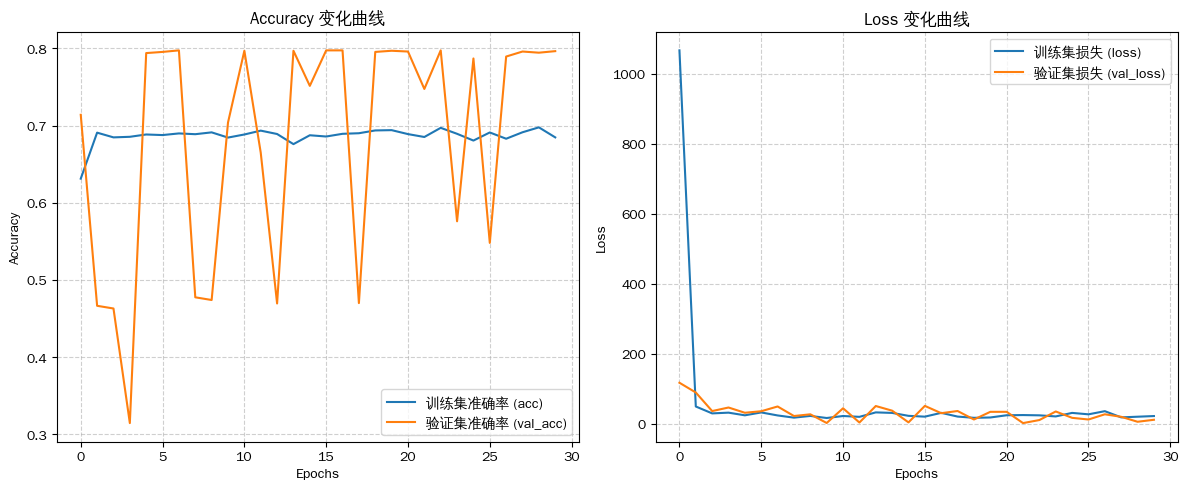

In [28]:
import matplotlib.pyplot as plt

# 设置画布
plt.figure(figsize=(12, 5))

# --- 图1：准确率 (acc vs val_acc) ---
plt.subplot(1, 2, 1) #“1行2列”的图表矩阵，并选中左侧第1个位置
plt.plot(history.history['acc'], label='训练集准确率 (acc)', color='#1f77b4') #history变量名.history属性名
plt.plot(history.history['val_acc'], label='验证集准确率 (val_acc)', color='#ff7f0e')
plt.title('Accuracy 变化曲线')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6) #图表添加网格线 alpha透明度

# --- 图2：损失函数 (loss vs val_loss) ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='训练集损失 (loss)', color='#1f77b4')
plt.plot(history.history['val_loss'], label='验证集损失 (val_loss)', color='#ff7f0e')
plt.title('Loss 变化曲线')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() #自动调整子图的布局
plt.show()

In [ ]:
# 1. 先分出 20% 的测试集
x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, test_size=0.2)

# 2. 再从剩下的 80% 中分出 20% 作为验证集
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2)

# 3. 训练时使用验证集
history = ann.fit(x_train, y_train, ..., validation_data=(x_val, y_val))

# 4. 全部训练完成后，用从未露面的测试集做最后评估
results = ann.evaluate(x_test, y_test)